In [1]:
import pandas as pd
import glob
import os

sites = ["GSFC", "HU_IRB", "SERC"]

for site in sites:
    files = sorted(glob.glob(f"../data/{site}/Raw/{site}_raw_*_AOD15_directsun.csv"))
    print(f"\n{site}: {len(files)} files found")

    dfs = []
    for f in files:
        df_tmp = pd.read_csv(f, skiprows=5, na_values=["-999", "-999.000000"])
        df_tmp["datetime"] = pd.to_datetime(
            df_tmp["Date(dd:mm:yyyy)"] + " " + df_tmp["Time(hh:mm:ss)"],
            format="%d:%m:%Y %H:%M:%S"
        )
        df_tmp = df_tmp[["datetime", "AOD_500nm"]].dropna()
        dfs.append(df_tmp)

    combined = pd.concat(dfs, ignore_index=True).sort_values("datetime").reset_index(drop=True)

    out_path = f"../data/{site}_AOD15_combined.csv"
    combined.to_csv(out_path, index=False)
    print(f"  Saved: {out_path}  |  shape: {combined.shape}")



GSFC: 6 files found


/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_92223/1521906896.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tmp["datetime"] = pd.to_datetime(
/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_92223/1521906896.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tmp["datetime"] = pd.to_datetime(
/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_92223/1521906896.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, w

  Saved: ../data/GSFC_AOD15_combined.csv  |  shape: (88221, 2)

HU_IRB: 4 files found


/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_92223/1521906896.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tmp["datetime"] = pd.to_datetime(
/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_92223/1521906896.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tmp["datetime"] = pd.to_datetime(
/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_92223/1521906896.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, w

  Saved: ../data/HU_IRB_AOD15_combined.csv  |  shape: (41388, 2)

SERC: 5 files found
  Saved: ../data/SERC_AOD15_combined.csv  |  shape: (39393, 2)


/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_92223/1521906896.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tmp["datetime"] = pd.to_datetime(
/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_92223/1521906896.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_tmp["datetime"] = pd.to_datetime(
/var/folders/7w/185lc4cj7mj1cc85b90sl1j80000gn/T/ipykernel_92223/1521906896.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, w

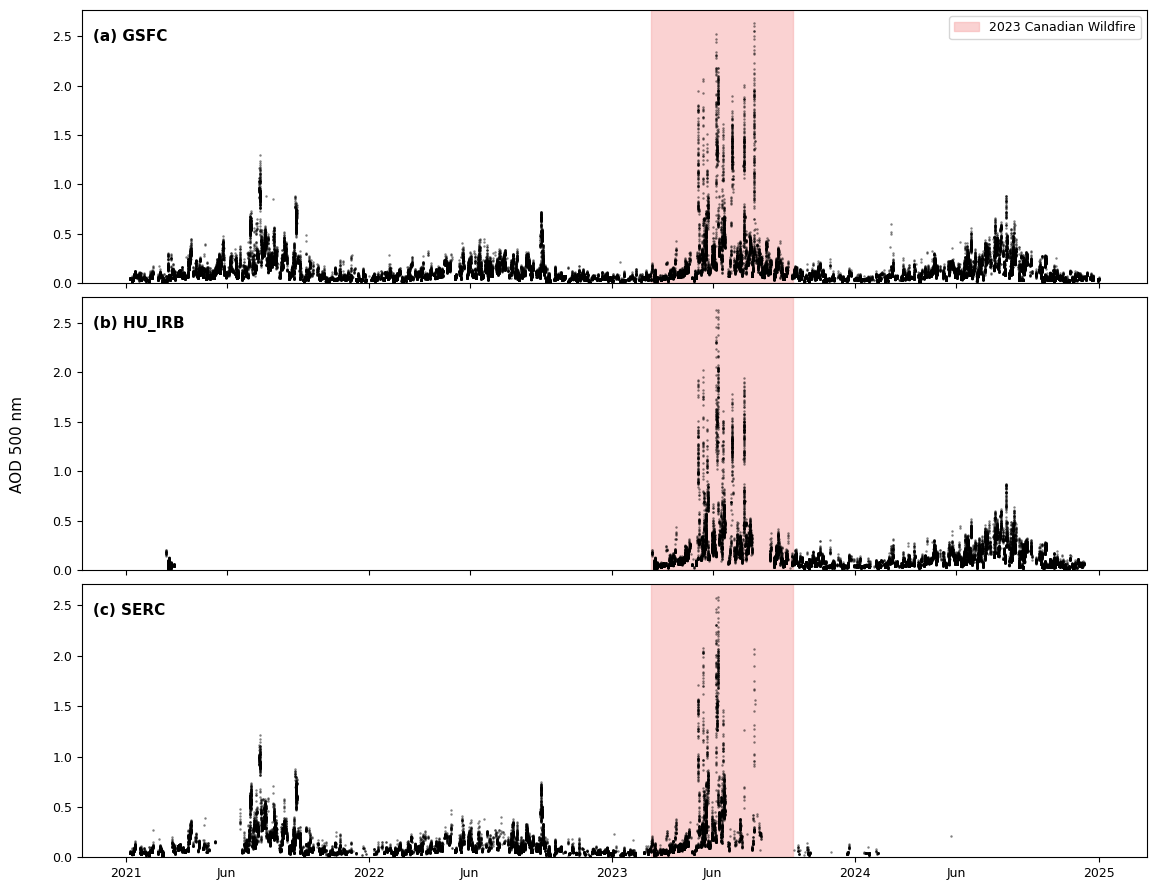

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sites  = ["GSFC", "HU_IRB", "SERC"]
labels = ["(a)", "(b)", "(c)"]

highlight_start = pd.Timestamp("2023-03-01")
highlight_end   = pd.Timestamp("2023-09-30")

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, sharey=False)

for ax, site, label in zip(axes, sites, labels):
    df = pd.read_csv(f"../data/{site}_AOD15_combined.csv", parse_dates=["datetime"])
    df = df.dropna(subset=["AOD_500nm"]).sort_values("datetime")
    df = df[df["datetime"].dt.year.between(2021, 2024)]

    ax.axvspan(highlight_start, highlight_end,
               color="#f8b4b4", alpha=0.6, zorder=0, label="2023 Canadian Wildfire")

    ax.scatter(df["datetime"], df["AOD_500nm"],
               s=3, color="black", alpha=0.5, linewidths=0, zorder=2)

    ax.text(0.01, 0.93, f"{label} {site}", transform=ax.transAxes,
            fontsize=11, fontweight="bold", va="top")

    ax.set_ylim(bottom=0)
    ax.tick_params(labelsize=9)

    if ax == axes[0]:
        ax.legend(loc="upper right", fontsize=9, frameon=True, framealpha=0.8)

fig.text(0.04, 0.5, "AOD 500 nm", va="center", rotation="vertical", fontsize=11)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 6]))

def custom_fmt(x, pos=None):
    dt = mdates.num2date(x)
    return str(dt.year) if dt.month == 1 else "Jun"

axes[-1].xaxis.set_major_formatter(plt.FuncFormatter(custom_fmt))

fig.canvas.draw()
for tick in axes[-1].xaxis.get_major_ticks():
    if tick.label1.get_text() == "Jun":
        tick.tick1line.set_visible(False)
        tick.tick2line.set_visible(False)

axes[-1].tick_params(axis="x", labelsize=9)

plt.tight_layout(h_pad=0.4)
plt.subplots_adjust(left=0.1)
# plt.savefig("../data/AOD15_time_series.png", dpi=300, bbox_inches="tight")
plt.show()
